In [1]:
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')    # Windows 내장
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')      # macOS
else:
    plt.rc('font', family='NanumGothic')      # Ubuntu: sudo apt install fonts-nanum

plt.rc('axes', unicode_minus=False)           # 마이너스 기호 깨짐 방지

In [ ]:
# 데이터 불러오기
(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

# 데이터 스케일링
train_scale = train_input.reshape(-1, 28, 28, 1) / 255.0
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

# 데이터 분할
train_scaled, val_scaled, train_target, val_target = \
    train_test_split(train_scale, train_target, test_size=0.2)

In [3]:
# 모델 구성
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28, 1)))
model.add(keras.layers.Conv2D(32, 3, activation='relu', padding='same'))
model.add(keras.layers.MaxPool2D())
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       627,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 628,630 (2.40 MB)

 Trainable params: 628,630 (2.40 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# 모델 컴파일
model.compile(optimizer='adam',
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=['accuracy'],
              jit_compile=False)

early_stopping = keras.callbacks.EarlyStopping(patience=2, 
                                               restore_best_weights=True)

# 모델 학습
history = model.fit(train_scaled, train_target, 
                    epochs=20, 
                    callbacks=[early_stopping], 
                    validation_data=(val_scaled, val_target))

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8250 - loss: 0.5003 - val_accuracy: 0.8816 - val_loss: 0.3229
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8801 - loss: 0.3363 - val_accuracy: 0.8961 - val_loss: 0.2806
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8947 - loss: 0.2918 - val_accuracy: 0.9079 - val_loss: 0.2515
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9036 - loss: 0.2662 - val_accuracy: 0.9121 - val_loss: 0.2450
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9102 - loss: 0.2452 - val_accuracy: 0.9108 - val_loss: 0.2481
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9151 - loss: 0.2288 - val_accuracy: 0.9140 - val_loss: 0.2467


In [5]:
# 검증 데이터 평가
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9121 - loss: 0.2450


[0.2450389415025711, 0.9120833277702332]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
예측 클래스 :  코트


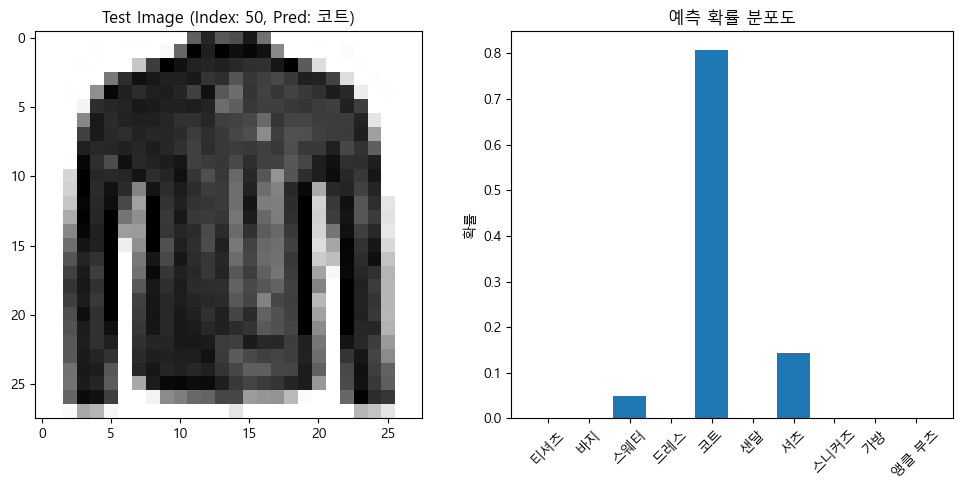

In [6]:
# 예측 (softmax로 10개의 클래스 확률 반환)
preds = model.predict(test_scaled[0:1]) 
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트',
           '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']

# 예측기
def predict_plot(n):
    preds = model.predict(test_scaled[n:n+1])
    print("예측 클래스 : ", classes[np.argmax(preds)])

    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(test_scaled[n], cmap='gray_r')
    axes[0].set_title(f"Test Image (Index: {n}, Pred: {classes[np.argmax(preds)]})")

    axes[1].bar(range(1, 11), preds[0])
    axes[1].set_xticks(range(1, 11))
    axes[1].set_xticklabels(classes, rotation=45)
    axes[1].set_ylabel('확률')
    axes[1].set_title('예측 확률 분포도')

    plt.tight_layout()
    plt.show()

predict_plot(50)